# Check ensemble padding

Notebook minimo para debuggear el flujo de generacion entre `src/ensemble.py` y `DiffusionModel._prepare_backbone_inputs` usando `lengths`.


In [1]:
from pathlib import Path
import os
import sys
import types

import torch as tr

def repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'src').exists() and (p / 'data').exists():
            return p.resolve()
    raise RuntimeError('Run this notebook from inside the repo.')

ROOT = repo_root()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.data import build_dataloader
from src.ensemble import _sample_batch
from src.io import load_model_checkpoint

tr.set_printoptions(precision=4, sci_mode=False)
DEVICE = tr.device('cuda' if tr.cuda.is_available() else 'cpu')
print('ROOT =', ROOT)
print('DEVICE =', DEVICE)


ROOT = /home/gkulemeyer/Documents/Repos/RNADiffusion
DEVICE = cuda


In [2]:
checkpoint_candidates = sorted(
    ROOT.glob('logs/**/checkpoints/best.ckpt'),
    key=lambda p: p.stat().st_mtime,
)
assert checkpoint_candidates, 'No encontre checkpoints best.ckpt en logs/**/checkpoints/'

CHECKPOINT_PATH = checkpoint_candidates[-1]
EXPERIMENT_DIR = CHECKPOINT_PATH.parent.parent
CONFIG_PATH = EXPERIMENT_DIR / 'config.yaml'

print('CHECKPOINT_PATH =', CHECKPOINT_PATH)
print('EXPERIMENT_DIR =', EXPERIMENT_DIR)
print('CONFIG_PATH =', CONFIG_PATH)

config = load_config(CONFIG_PATH)
config['training']['batch_size'] = max(2, int(config['training'].get('batch_size', 4)))
config['training']['num_workers'] = 0

model = load_model_checkpoint(config, CHECKPOINT_PATH, eval_mode=True)
print('model class =', model.__class__.__name__)
print('model device =', next(model.parameters()).device)


CHECKPOINT_PATH = /home/gkulemeyer/Documents/Repos/RNADiffusion/logs/ArchiveII_ff128/srp/t10/bd32/bs1_acc4/seed42/train/checkpoints/best.ckpt
EXPERIMENT_DIR = /home/gkulemeyer/Documents/Repos/RNADiffusion/logs/ArchiveII_ff128/srp/t10/bd32/bs1_acc4/seed42/train
CONFIG_PATH = /home/gkulemeyer/Documents/Repos/RNADiffusion/logs/ArchiveII_ff128/srp/t10/bd32/bs1_acc4/seed42/train/config.yaml
model class = DiffusionModel
model device = cuda:0


In [3]:
loader = build_dataloader(config, partition='test', shuffle=False)
batch = next(iter(loader)) 
 
assert len(batch['length']) >= 2, 'Necesito al menos 2 secuencias en el batch para probar repeat_interleave.'
 
conditioning = batch['conditioning'][:2].to(DEVICE)
targets = batch['contact_oh'][:2].to(DEVICE)
lengths = tr.tensor(batch['length'][:2], dtype=tr.long, device=DEVICE)
 

In [4]:
print('batch keys =', sorted(batch.keys()))
print('batch lengths =', batch['length'])
print('conditioning shape =', tuple(batch['conditioning'].shape))
print('contact_oh shape =', tuple(batch['contact_oh'].shape)) 
print('selected lengths =', lengths.tolist())
print('selected conditioning shape =', tuple(conditioning.shape))
print('selected targets shape =', tuple(targets.shape))


batch keys = ['conditioning', 'contact', 'contact_oh', 'embedding', 'id', 'length', 'mask', 'sequence']
batch lengths = [111, 113]
conditioning shape = (2, 16, 116, 116)
contact_oh shape = (2, 2, 116, 116)
selected lengths = [111, 113]
selected conditioning shape = (2, 16, 116, 116)
selected targets shape = (2, 2, 116, 116)


In [5]:
orig_prepare = model._prepare_backbone_inputs

def debug_prepare(self, xt_input, condition, lengths=None):
    print('\n[_prepare_backbone_inputs]')
    print('  xt_input shape =', tuple(xt_input.shape))
    print('  condition shape =', tuple(condition.shape))
    if lengths is None:
        print('  lengths = None')
    else:
        lengths_t = tr.as_tensor(lengths, device=condition.device, dtype=tr.long)
        print('  lengths shape =', tuple(lengths_t.shape), 'values =', lengths_t.tolist())
        mask = self._lengths_to_mask(lengths_t, condition.shape[-1], device=condition.device)
        print('  derived mask shape =', tuple(mask.shape))
        print('  batch match =', mask.shape[0] == condition.shape[0])
    xt_backbone, cond_backbone = orig_prepare(xt_input, condition, lengths=lengths)
    print('  xt_backbone shape =', tuple(xt_backbone.shape))
    print('  cond_backbone shape =', tuple(cond_backbone.shape))
    if lengths is not None:
        l0 = int(tr.as_tensor(lengths, device=condition.device, dtype=tr.long)[0].item())
        if l0 < xt_backbone.shape[-1]:
            print('  xt padded pixel sample  =', xt_backbone[0, :, l0, l0].detach().cpu())
            print('  cond padded pixel sample =', cond_backbone[0, :4, l0, l0].detach().cpu())
    return xt_backbone, cond_backbone

model._prepare_backbone_inputs = types.MethodType(debug_prepare, model)
print('debug wrapper installed')


debug wrapper installed


In [6]:
current_chunk = 3
expanded_conditioning = conditioning.repeat_interleave(current_chunk, dim=0)
expanded_lengths = lengths.repeat_interleave(current_chunk)
dummy_xt = tr.zeros(
    (expanded_conditioning.shape[0], expanded_conditioning.shape[-2], expanded_conditioning.shape[-1]),
    device=DEVICE,
    dtype=tr.long,
)

print('manual ensemble-style expansion')
print('  expanded_conditioning shape =', tuple(expanded_conditioning.shape))
print('  expanded_lengths shape =', tuple(expanded_lengths.shape), 'values =', expanded_lengths.tolist())
print('  batch sizes match =', expanded_conditioning.shape[0] == expanded_lengths.shape[0])

xt_backbone, cond_backbone = model._prepare_backbone_inputs(
    dummy_xt,
    expanded_conditioning,
    lengths=expanded_lengths,
)

print('\nmanual call completed')
print('  xt_backbone dtype =', xt_backbone.dtype)
print('  cond_backbone dtype =', cond_backbone.dtype)


manual ensemble-style expansion
  expanded_conditioning shape = (6, 16, 92, 92)
  expanded_lengths shape = (6,) values = [75, 75, 75, 76, 76, 76]
  batch sizes match = True

[_prepare_backbone_inputs]
  xt_input shape = (6, 92, 92)
  condition shape = (6, 16, 92, 92)
  lengths shape = (6,) values = [75, 75, 75, 76, 76, 76]
  derived mask shape = (6, 1, 92, 92)
  batch match = True
  xt_backbone shape = (6, 2, 92, 92)
  cond_backbone shape = (6, 16, 92, 92)
  xt padded pixel sample  = tensor([1., 0.])
  cond padded pixel sample = tensor([0., 0., 0., 0.])

manual call completed
  xt_backbone dtype = torch.float32
  cond_backbone dtype = torch.float32


In [5]:
NUM_SAMPLES = 3
CHUNK_SIZE = 2
BASE_SEED = 123

samples = _sample_batch(
    model=model,
    conditioning=conditioning,
    lengths=lengths,
    num_samples=NUM_SAMPLES,
    base_seed=BASE_SEED,
    chunk_size=CHUNK_SIZE,
)

print('\n_sample_batch output')
print('  samples shape =', tuple(samples.shape))
print('  samples dtype =', samples.dtype)
print('  expected shape =', (conditioning.shape[0], NUM_SAMPLES, conditioning.shape[-2], conditioning.shape[-1]))
print('  shape ok =', tuple(samples.shape) == (conditioning.shape[0], NUM_SAMPLES, conditioning.shape[-2], conditioning.shape[-1]))

for i, length in enumerate(lengths.tolist()):
    padded_value = None
    if length < samples.shape[-1]:
        padded_value = int(samples[i, 0, length, length].item())
    print(f'  seq {i}: length={length}, padded sample value at [length, length] = {padded_value}')



_sample_batch output
  samples shape = (2, 3, 116, 116)
  samples dtype = torch.int8
  expected shape = (2, 3, 116, 116)
  shape ok = True
  seq 0: length=111, padded sample value at [length, length] = 0
  seq 1: length=113, padded sample value at [length, length] = 0


In [6]:
current_chunk = 2

expanded_conditioning = conditioning.repeat_interleave(
    current_chunk,
    dim=0
)
expanded_lengths = lengths.repeat_interleave(current_chunk)

tr.manual_seed(BASE_SEED)

with tr.inference_mode():
    raw_samples = model.sample(
        expanded_conditioning,
        lengths=expanded_lengths
    )

print("Direct model.sample output")
print("  shape  =", tuple(raw_samples.shape))
print("  ndim   =", raw_samples.ndim)
print("  dtype  =", raw_samples.dtype)
print("  unique =", tr.unique(raw_samples).cpu())

Direct model.sample output
  shape  = (4, 116, 116)
  ndim   = 3
  dtype  = torch.int64
  unique = tensor([0, 1])


In [7]:
print(expanded_lengths)

tensor([111, 111, 113, 113], device='cuda:0')


In [8]:
x = model.sample(
    condition=conditioning,
    lengths=lengths,
)

In [9]:
x, l = model.sample(
    condition=conditioning,
    lengths=lengths,
    return_logits=True
)

In [10]:
x.shape, l.shape

(torch.Size([2, 116, 116]), torch.Size([2, 2, 116, 116]))

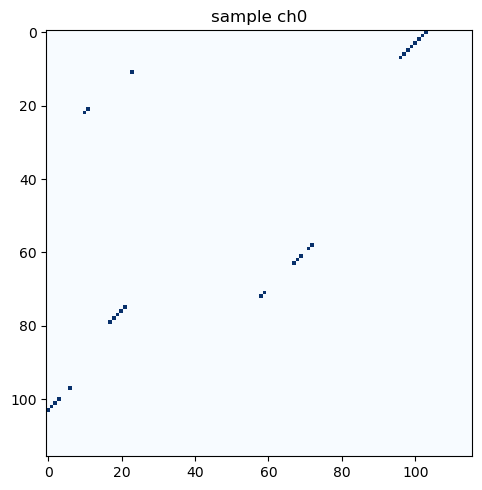

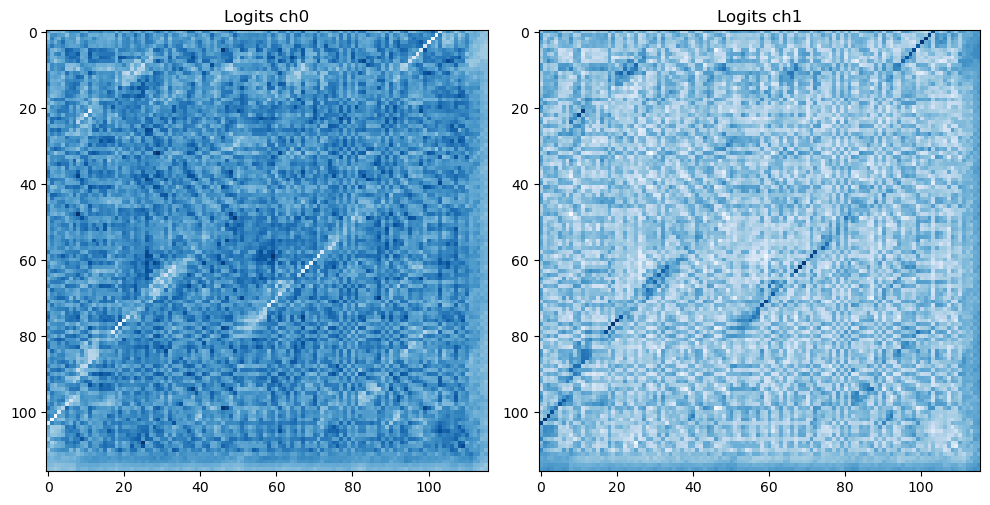

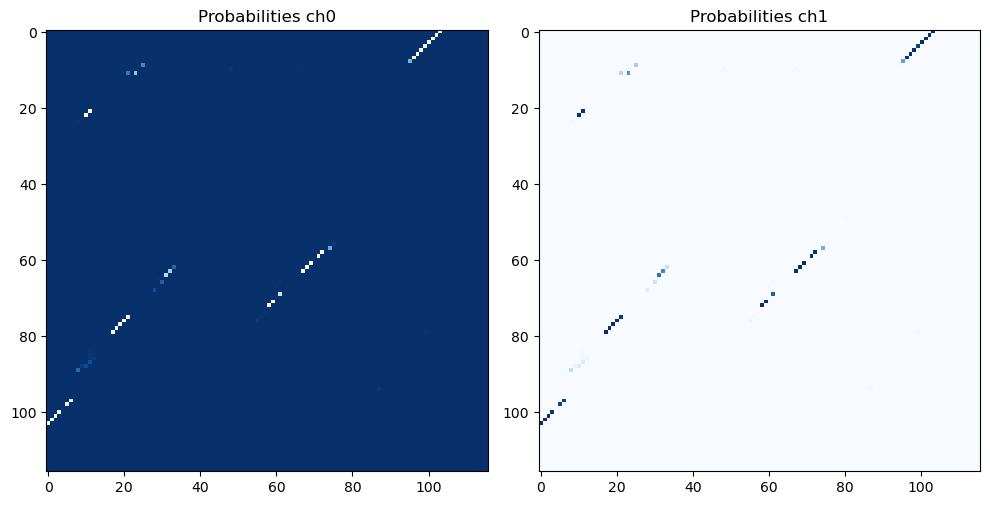

In [11]:
import matplotlib.pyplot as plt
from torch.nn import functional as F

fig, ax = plt.subplots(1,   1, figsize=(5, 5))
ax.imshow(x[0].cpu(), cmap="Blues")
# ax[1].imshow(x[].cpu(), cmap="Blues") 
ax.set_title(f'sample ch0')
# ax[1].set_title(f'sample ch1')
fig.tight_layout()
plt.show()



fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(l[0, 0].cpu(), cmap="Blues")
ax[1].imshow(l[0, 1].cpu(), cmap="Blues") 
ax[0].set_title(f'Logits ch0')
ax[1].set_title(f'Logits ch1')
fig.tight_layout()
plt.show()


l_prob = F.softmax(l, dim=1) 
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(l_prob[0, 0].cpu(), cmap="Blues")
ax[1].imshow(l_prob[0, 1].cpu(), cmap="Blues")

ax[0].set_title(f'Probabilities ch0')
ax[1].set_title(f'Probabilities ch1')
 
fig.tight_layout()
plt.show()

In [28]:
print(l_prob[0,0,:,:].cpu().mean(),l_prob[0,1,:,:].cpu().mean(),)

tensor(0.9975) tensor(0.0025)


In [12]:

l_prob = F.softmax(l[:,:,:,:], dim=1) 
l_prob

tensor([[[[    1.0000,     1.0000,     1.0000,  ...,     1.0000,
               1.0000,     0.9999],
          [    1.0000,     1.0000,     1.0000,  ...,     1.0000,
               1.0000,     1.0000],
          [    0.9999,     1.0000,     1.0000,  ...,     1.0000,
               1.0000,     1.0000],
          ...,
          [    1.0000,     1.0000,     1.0000,  ...,     1.0000,
               1.0000,     1.0000],
          [    1.0000,     1.0000,     1.0000,  ...,     1.0000,
               1.0000,     0.9999],
          [    1.0000,     1.0000,     0.9998,  ...,     1.0000,
               0.9999,     1.0000]],

         [[    0.0000,     0.0000,     0.0000,  ...,     0.0000,
               0.0000,     0.0001],
          [    0.0000,     0.0000,     0.0000,  ...,     0.0000,
               0.0000,     0.0000],
          [    0.0001,     0.0000,     0.0000,  ...,     0.0000,
               0.0000,     0.0000],
          ...,
          [    0.0000,     0.0000,     0.0000,  ...,     0.

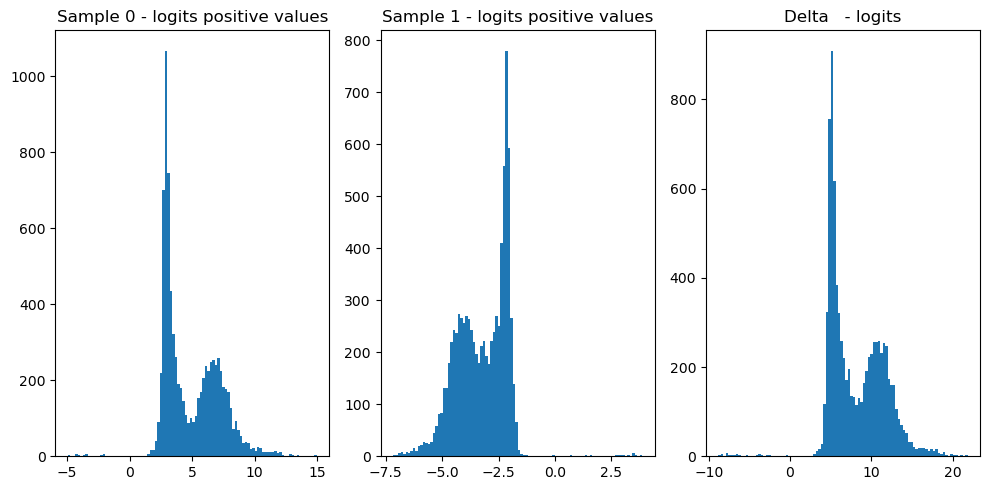

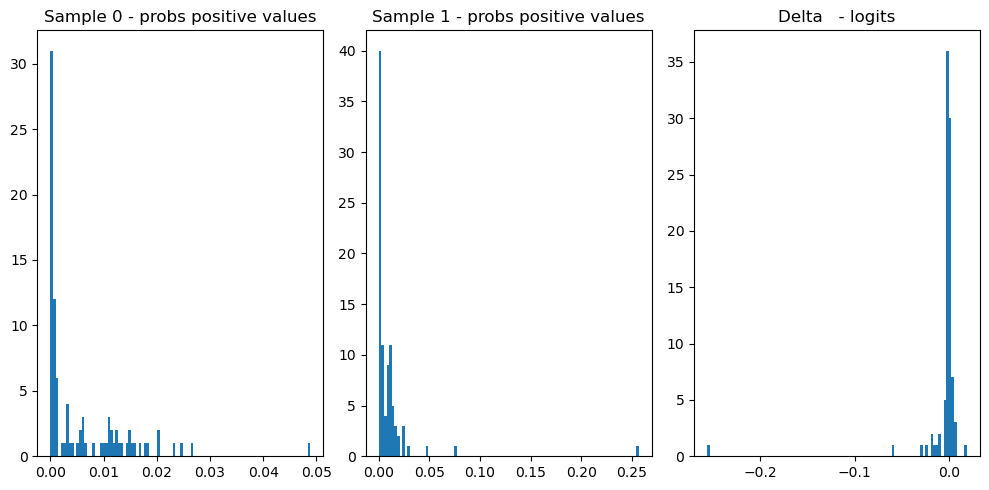

In [ ]:

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].hist(l[0, 0].flatten().cpu(), bins=100)
ax[1].hist(l[0, 1].flatten().cpu(), bins=100)
delta = (l[0,0] - l[0,1]).cpu() 
ax[2].hist(delta.flatten(), bins=100)  # Example of combining samples for visualization

ax[0].set_title(f'Sample 0 - logits positive values')
ax[1].set_title(f'Sample 1 - logits positive values')
ax[2].set_title(f'Delta   - logits') 
fig.tight_layout()
plt.show()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
L0_prob = l_prob[0, 0].flatten().cpu()
L1_prob = l_prob[0, 1].flatten().cpu()
deltaL_prob = (l_prob[0,0] - l_prob[0,1]).flatten().cpu()

ax[0].hist(L0_prob, bins=100)
ax[1].hist(L1_prob, bins=100)
ax[2].hist(deltaL_prob, bins=100)  # Example of combining samples for visualization

ax[0].set_title(f'Sample 0 - probs positive values')
ax[1].set_title(f'Sample 1 - probs positive values')
ax[2].set_title(f'Delta   - logits') 
fig.tight_layout()
plt.show()

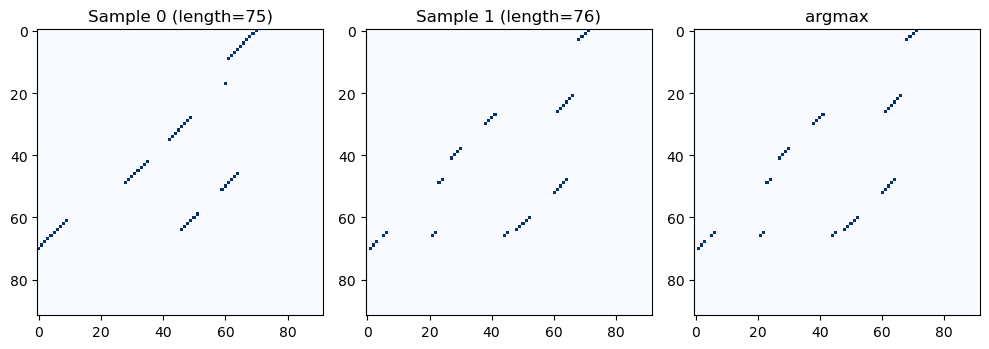

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(x[0].cpu(), cmap="Blues")
ax[1].imshow(x[1].cpu(), cmap="Blues")
ax[2].imshow(x.argmax(dim=0).cpu(), cmap="Blues")  # Example of combining samples for visualization

ax[0].set_title(f'Sample 0 (length={lengths[0].item()})')
ax[1].set_title(f'Sample 1 (length={lengths[1].item()})')
ax[2].set_title(f'argmax')
fig.tight_layout()
plt.show()

In [22]:

expanded_conditioning = conditioning.repeat_interleave(
    current_chunk,
    dim=0
)

with tr.inference_mode():
    sampled = model.sample(
        expanded_conditioning,
        lengths=expanded_lengths
    )

print("Salida directa de model.sample")
print("shape:", sampled.shape)
print("ndim:", sampled.ndim)
print("dtype:", sampled.dtype)
print("unique:", tr.unique(sampled))
print("min/max:", sampled.min().item(), sampled.max().item())

before_processing = sampled.clone()

if sampled.ndim == 4:
    print("Se aplica argmax sobre la dimensión de clases")
    sampled = sampled.argmax(dim=1)
elif sampled.ndim == 2:
    print("Se agrega una dimensión de batch")
    sampled = sampled.unsqueeze(0)
else:
    print("No se aplica argmax ni unsqueeze")

print("\nDespués del procesamiento")
print("shape:", sampled.shape)
print("dtype:", sampled.dtype)
print("unique:", tr.unique(sampled))

if before_processing.ndim == 3:
    print(
        "¿Cambió el contenido?",
        not tr.equal(before_processing, sampled)
    )

NameError: name 'current_chunk' is not defined